In [ ]:
import os
import sys
from scipy import optimize
import numpy as np
import pickle
from pyscf import gto, scf, dft
import matplotlib.pyplot as plt
import psutil
from pyscf.dft import numint
from pyscf.scf import chkfile as scfchk
from pyscf.scf.addons import remove_linear_dep_

In [45]:
def find_y(rhol, rhor):
    tot_rho = (rhol + rhor).sum(axis=(0,2))
    y_index = np.argmax(tot_rho)
    return y_index

def find_x(rhol, rhor):
    tot_rho = (rhol + rhor).sum(axis=(1,2))
    x_index = np.argmax(tot_rho)
    return x_index

def find_z(rhol, rhor):
    tot_rho = (rhol + rhor).sum(axis=(0,1))
    z_index = np.argmax(tot_rho)
    return z_index


In [ ]:
### ---- 2.1 Data ----
data = np.load("2.1dens3D.npz")
xaxis = data['x']
yaxis = data['y']
zaxis = data['z']
x, y, z = np.meshgrid(xaxis, yaxis, zaxis, indexing='ij') #use matrix indexing to keep x, y, z
#three arrays shape (nx, ny, nz), change to 1D array and combine
stacked_coords = np.column_stack([
    x.ravel(),
    y.ravel(),
    z.ravel()
]) #in angstrom, change to bohr
stacked_coords *= 1.8897259886
rhol = data['rhol']
rhor = data['rhor']


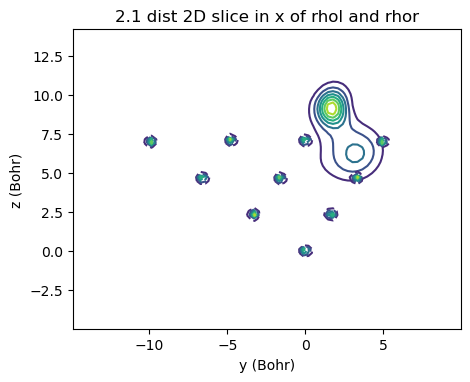

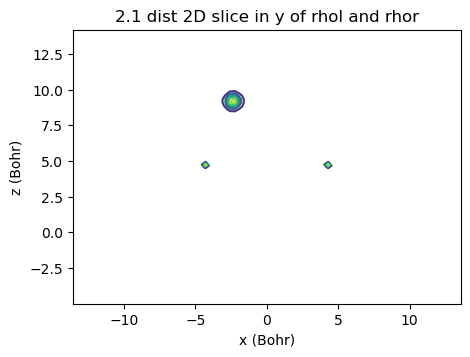

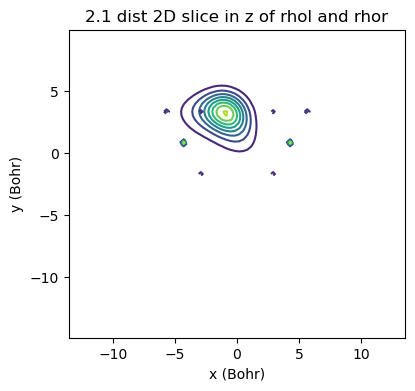

In [59]:
# 2.1 Plots

# --- Make Slice (x) ---
x_index = find_x(rhol, rhor)
plot_rholx = rhol[x_index, :, :]
plot_rhorx = rhor[x_index, :, :]

Y, Z = np.meshgrid(yaxis, zaxis, indexing='ij')

# --- Plot ---
plt.figure(figsize=(5, 4))
plt.contour(Y, Z, plot_rholx, levels=8)
plt.contour(Y, Z, plot_rhorx, levels=8, linestyles="dashed")
plt.xlabel("y (Bohr)")
plt.ylabel("z (Bohr)")
plt.title(f"2.1 dist 2D slice in x of rhol and rhor")
plt.gca().set_aspect("equal")
#plt.xlim(-6,6)
#plt.ylim(4,10)
plt.show()

# --- Make Slice (y) ---
y_index = find_y(rhol, rhor)
plot_rholy = rhol[:, y_index, :]
plot_rhory = rhor[:, y_index, :]

X, Z = np.meshgrid(xaxis, zaxis, indexing='ij')

# --- Plot ---
plt.figure(figsize=(5, 4))
plt.contour(X, Z, plot_rholy, levels=8)
plt.contour(X, Z, plot_rhory, levels=8, linestyles="dashed")
plt.xlabel("x (Bohr)")
plt.ylabel("z (Bohr)")
plt.title(f"2.1 dist 2D slice in y of rhol and rhor")
plt.gca().set_aspect("equal")
#plt.xlim(-6,6)
#plt.ylim(4,10)
plt.show()

# --- Make Slice (z) ---
z_index = find_z(rhol, rhor)
plot_rholz = rhol[:, :, z_index]
plot_rhorz = rhor[:, :, z_index]

X, Y = np.meshgrid(xaxis, yaxis, indexing='ij')

# --- Plot ---
plt.figure(figsize=(5, 4))
plt.contour(X, Y, plot_rholz, levels=8)
plt.contour(X, Y, plot_rhorz, levels=8, linestyles="dashed")
plt.xlabel("x (Bohr)")
plt.ylabel("y (Bohr)")
plt.title(f"2.1 dist 2D slice in z of rhol and rhor")
plt.gca().set_aspect("equal")
#plt.xlim(-6,6)
#plt.ylim(4,10)
plt.show()


In [60]:
# 2.7 data
data = np.load("2.7dens3D.npz")
xaxis = data['x']
yaxis = data['y']
zaxis = data['z']
x, y, z = np.meshgrid(xaxis, yaxis, zaxis, indexing='ij') #use matrix indexing to keep x, y, z
#three arrays shape (nx, ny, nz), change to 1D array and combine
stacked_coords = np.column_stack([
    x.ravel(),
    y.ravel(),
    z.ravel()
]) #in angstrom, change to bohr
stacked_coords *= 1.8897259886
rhol = data['rhol']
rhor = data['rhor']

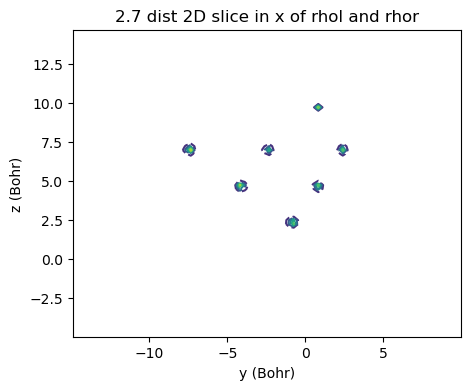

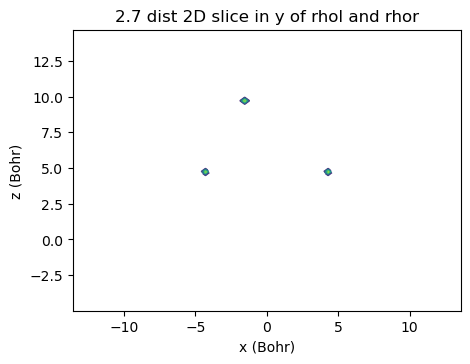

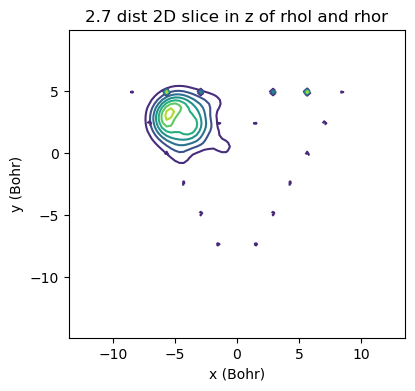

In [62]:
# 2.7 Plots

# --- Make Slice (x) ---
x_index = find_x(rhol, rhor)
plot_rholx = rhol[x_index, :, :]
plot_rhorx = rhor[x_index, :, :]

Y, Z = np.meshgrid(yaxis, zaxis, indexing='ij')

# --- Plot ---
plt.figure(figsize=(5, 4))
plt.contour(Y, Z, plot_rholx, levels=8)
plt.contour(Y, Z, plot_rhorx, levels=8, linestyles="dashed")
plt.xlabel("y (Bohr)")
plt.ylabel("z (Bohr)")
plt.title(f"2.7 dist 2D slice in x of rhol and rhor")
plt.gca().set_aspect("equal")
#plt.xlim(-6,6)
#plt.ylim(4,10)
plt.show()

# --- Make Slice (y) ---
y_index = find_y(rhol, rhor)
plot_rholy = rhol[:, y_index, :]
plot_rhory = rhor[:, y_index, :]

X, Z = np.meshgrid(xaxis, zaxis, indexing='ij')

# --- Plot ---
plt.figure(figsize=(5, 4))
plt.contour(X, Z, plot_rholy, levels=8)
plt.contour(X, Z, plot_rhory, levels=8, linestyles="dashed")
plt.xlabel("x (Bohr)")
plt.ylabel("z (Bohr)")
plt.title(f"2.7 dist 2D slice in y of rhol and rhor")
plt.gca().set_aspect("equal")
#plt.xlim(-6,6)
#plt.ylim(4,10)
plt.show()

# --- Make Slice (z) ---
z_index = find_z(rhol, rhor)
plot_rholz = rhol[:, :, z_index]
plot_rhorz = rhor[:, :, z_index]

X, Y = np.meshgrid(xaxis, yaxis, indexing='ij')

# --- Plot ---
plt.figure(figsize=(5, 4))
plt.contour(X, Y, plot_rholz, levels=8)
plt.contour(X, Y, plot_rhorz, levels=8, linestyles="dashed")
plt.xlabel("x (Bohr)")
plt.ylabel("y (Bohr)")
plt.title(f"2.7 dist 2D slice in z of rhol and rhor")
plt.gca().set_aspect("equal")
#plt.xlim(-6,6)
#plt.ylim(4,10)
plt.show()
